In [1]:
import os
os.chdir('../../../../..')

In [35]:
import numpy as np

from sklearn.cluster import AgglomerativeClustering, SpectralClustering, DBSCAN, KMeans
from kmedoids import KMedoids
from hdbscan import HDBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

from src.datasets import QM9Dataset
from src.helper_functions import plot_molecules_with_py3dmol, create_chemiscope_viewer, plot_distance_matrix_projection, evaluate_distance_matrix_clustering_sweep, average_numeric_by_cluster, evaluate_hdbscan_grid

In [3]:
qm9 = QM9Dataset(limit=5000, sampling_strategy="stratified", stratify_by=["num_atoms", "gap"], descriptors=["chemprop"])
df = qm9.load()
molecules = qm9.get_molecules()

2026-04-27 09:47:39.228 | INFO     | src.datasets:load:818 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-04-27 09:47:39.590 | INFO     | src.datasets:_sample_qm9_df:1018 - QM9 sampling complete: strategy=stratified, requested_limit=5000, returned_rows=5000.
2026-04-27 09:47:39.590 | INFO     | src.datasets:_add_requested_descriptors:199 - Applying requested QM9 descriptors to sampled dataframe (rows=5000).
2026-04-27 09:47:39.591 | INFO     | src.features:compute_chemprop_embeddings:474 - Computing Chemprop embeddings on mps...
2026-04-27 09:47:39.591 | WARNING  | src.features:compute_chemprop_embeddings:482 - No model_path provided. Using RANDOM (untrained) MPNN weights.
2026-04-27 09:47:43.535 | INFO     | src.datasets:_add_requested_descriptors:224 - Added descriptor column(s): ['chemprop_embedding']
2026-04-27 09:48:05.498 | SUCCESS  | src.datasets:get_molecules:1588 - Saved 5000 molecules to data/QM9/qm9_subset.xyz (failed: 0, requested: 5000).


In [4]:
len(df['chemprop_embedding'].to_list()[0])

4

In [5]:
len(molecules[0:2])

2

In [6]:
plot_molecules_with_py3dmol(molecules[0:3])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [7]:
dist_matrix = qm9.get_distance_matrix(
    descriptor="chemprop",
    dist_type="euclidean",
)

2026-04-27 09:48:05.568 | INFO     | src.datasets:get_distance_matrix:1419 - Calculating distance matrix for chemprop using euclidean distance.
2026-04-27 09:48:05.576 | INFO     | src.distance:get_matrix:29 - Loading cached distance matrix from data/QM9/dist_chemprop_euclidean.npy


# Determining the best number of clusters for each clustering method

Evaluating epsilon and min samples: 100%|██████████| 10/10 [00:10<00:00,  1.02s/it]


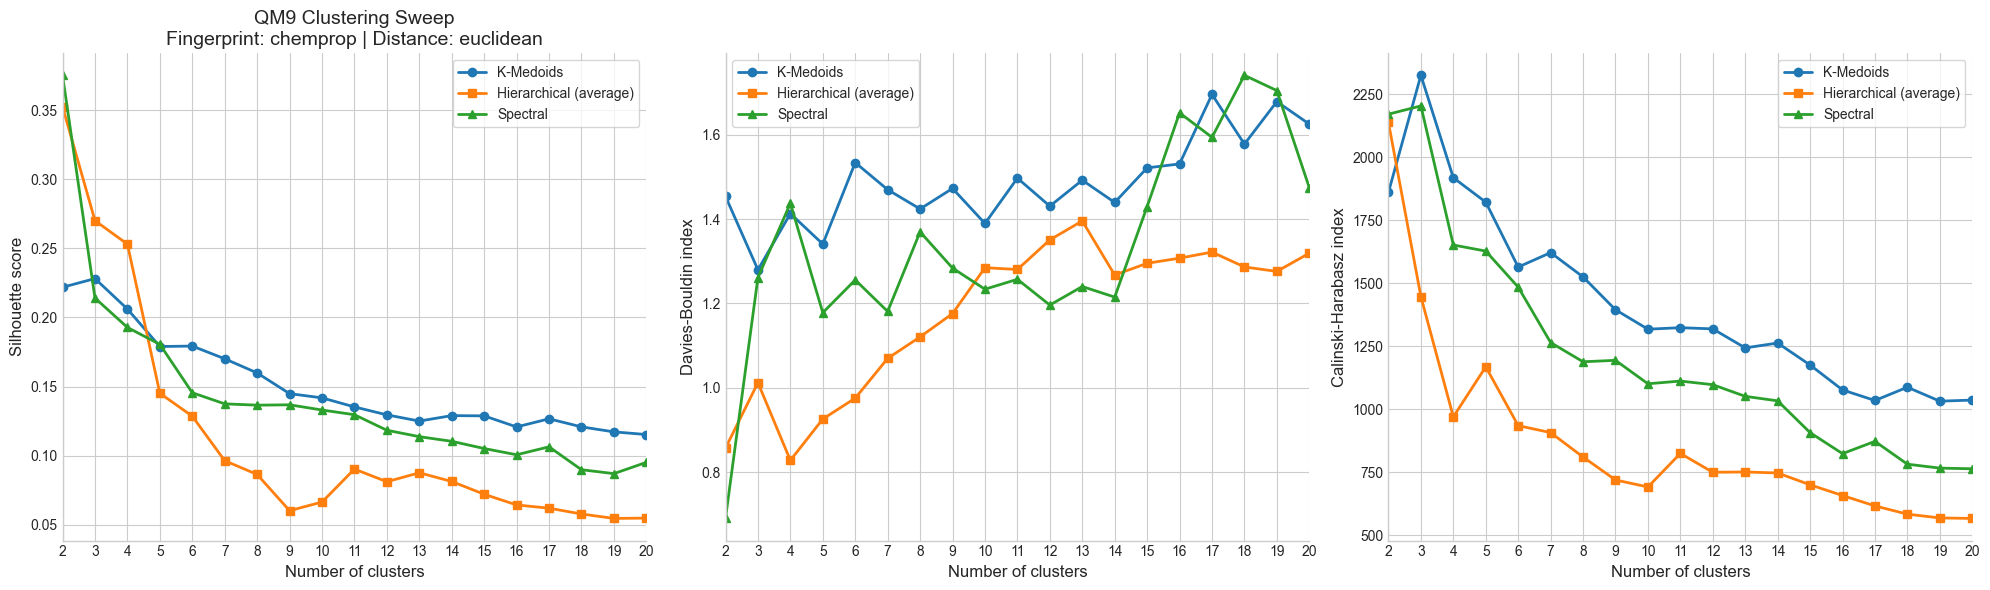

2026-04-27 09:49:14.836 | WARNING  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:962 - No valid DBSCAN parameter combinations produced clusterings to plot.
2026-04-27 09:49:14.841 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:984 - Saved clustering sweep plot to figures/qm9/clustering/euclidean/chemprop/clustering_sweep_2_to_20_clusters.png
2026-04-27 09:49:14.842 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:987 - Saved clustering sweep results to figures/qm9/clustering/euclidean/chemprop/clustering_sweep_2_to_20_clusters.json


In [8]:
out = evaluate_distance_matrix_clustering_sweep(
    dist_matrix=dist_matrix,
    fingerprint="chemprop",
    distance_metric="euclidean",
    dataset_name="qm9",
)

In [9]:
# find the n molecules that are not on the diagonal with the smallest distance
n = 10
# Get the indices of the upper triangle (excluding diagonal)
triu_indices = np.triu_indices_from(dist_matrix, k=1)
# Get the distances and corresponding molecule pairs
distances = dist_matrix[triu_indices]
molecule_pairs = list(zip(triu_indices[0], triu_indices[1]))
# Get the indices of the n smallest distances
smallest_indices = np.argsort(distances)[:n]
# Get the corresponding molecule pairs for the n smallest distances
closest_pairs = [molecule_pairs[i] for i in smallest_indices]
print("Closest molecule pairs (indices):", closest_pairs)
mols = [(molecules[idx1], molecules[idx2]) for idx1, idx2 in closest_pairs]

Closest molecule pairs (indices): [(np.int64(1332), np.int64(1333)), (np.int64(1648), np.int64(1685)), (np.int64(1195), np.int64(1196)), (np.int64(1236), np.int64(1239)), (np.int64(1288), np.int64(1299)), (np.int64(1073), np.int64(1075)), (np.int64(1176), np.int64(1180)), (np.int64(1128), np.int64(1129)), (np.int64(4533), np.int64(4658)), (np.int64(1373), np.int64(1377))]


In [10]:
print(mols[0])

(Atoms(symbols='H6CNHC5NC', pbc=False, initial_charges=..., mass=..., partial_charge=...), Atoms(symbols='H9C3HC4NC', pbc=False, initial_charges=..., mass=..., partial_charge=...))


In [11]:
plot_molecules_with_py3dmol(mols[5])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

# Hiercical Clustering on Distance Matrix

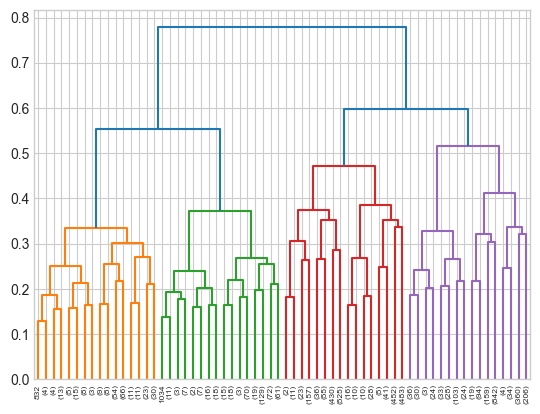

In [36]:
condensed_dist = squareform(dist_matrix)
Z = linkage(condensed_dist, method='complete')
a = dendrogram(
    Z,
    truncate_mode='level',
    p=5                
)

In [37]:
model_hier = AgglomerativeClustering(metric='precomputed', n_clusters=4, linkage='complete')
labels_hier = model_hier.fit_predict(dist_matrix)
df = df.with_columns(labels_hier=labels_hier)
print(np.unique(labels_hier, return_counts=True))

(array([0, 1, 2, 3]), array([1999,  452, 2284,  265]))


In [38]:
create_chemiscope_viewer(df, dist_matrix, labels_hier, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [39]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="chemprop",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_hier,
    clustering_method="hierarchical"
)

2026-04-27 10:15:37.972 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:529 - Saved PCA projection plot to figures/qm9/clustering/euclidean/chemprop/pca_hierarchical_projection.png


{'coords': array([[ 1.94465792,  1.26807265],
        [ 0.8428107 , -0.9843931 ],
        [-2.40426682,  0.92815135],
        ...,
        [-2.16796263, -0.95580889],
        [-3.2802515 , -0.07714778],
        [-3.88024773,  0.9635481 ]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/euclidean/chemprop/pca_hierarchical_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/euclidean/chemprop'),
 'clustering_method': 'hierarchical'}

In [40]:
average_numeric_by_cluster(df, "labels_hier")

shape: (4, 76)
┌─────────────┬───────┬───────────────┬─────────────┬────────────┬────────┬─────────┬───────────────┬──────────────┬──────────────┬───────────┬──────────────┬──────────────┬──────────────┬───────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬──────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬───────────┬──────────────┬───────────┬──────────────┬──────────────┬──────────────┬──────────────┬─────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬

labels_hier,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,…,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_km,labels_spectral,labels_db,labels_hdbscan,labels_kmeans,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,1999,2.056654,0.0,122.701851,0.067534,36.787394,0.864127,12.866836,8.747874,1.545273,0.122561,0.033517,2.444222,18.566783,2.048712,2.584792,0.06873,0.194773,0.736496,0.914957,2.005503,6.428214,0.43972,1.081041,4.782891,6.38019,38.563782,1.260418,0.004002,0.395698,0.011506,0.129065,0.117559,0.001501,0.038519,0.132566,…,2.662856,75.094172,-6.626253,0.318507,6.944738,1207.11492,4.125361,-11164.228781,-11163.992931,-11163.967224,-11165.144267,32.120064,-76.546494,-77.014046,-77.457439,-71.215349,313.502174,1.384232,1.108469,1.137069,0.0,0.0005,-0.047024,1.223612,75.087544,11.805903,13.106553,38.563782,677,"""Acyclic""",13.106553,164,"""Acyclic""",13.106553,1,null,0.0
1,452,1.897297,0.0,120.404867,0.212389,44.511062,0.758046,12.85811,8.727876,1.353982,0.752212,0.0,2.85177,16.336283,2.037995,2.061947,0.078132,0.565223,0.356644,1.214602,2.367257,6.323009,0.517699,3.115044,2.243363,6.504425,31.300885,1.255723,0.006637,0.150442,0.185841,0.267699,0.033186,0.002212,0.004425,0.024336,…,2.818354,74.726903,-5.927025,0.003305,5.930336,1156.490047,3.492124,-11116.107009,-11115.886254,-11115.860562,-11117.004446,30.02769,-70.6467,-71.048132,-71.437336,-65.904345,3.924531,1.400985,1.061057,0.0,0.006637,-0.002212,0.911504,0.955752,23.00885,72.787611,4.20354,31.300885,190,"""c1cc[nH]c1""",14.159292,42,"""C1CCCC1""",44.690265,1,null,0.0
2,2284,2.064404,0.0,123.053853,0.045972,35.345447,0.871649,12.842916,8.805604,1.771016,0.121716,0.02627,2.410683,18.377846,2.07307,2.112084,0.065243,0.200116,0.734641,0.870841,1.985114,6.535026,0.432137,1.149299,4.813485,6.315236,38.261384,1.265078,0.001751,0.340193,0.014448,0.121278,0.129159,0.001751,0.043783,0.128722,…,2.680131,75.150503,-6.57576,0.308106,6.883788,1183.904216,4.069533,-11198.610301,-11198.381072,-11198.35537,-11199.518044,31.495516,-76.307301,-76.774562,-77.213342,-71.014679,3.41099,1.406261,1.131528,1.656305,0.0,-0.005254,-0.00613,1.18958,78.940455,11.514886,9.544658,38.261384,972,"""Acyclic""",9.544658,270,"""C1CCCC1""",9.807356,1,null,0.0
3,265,2.103326,0.0,123.833962,0.075472,32.339623,0.877615,12.8214,8.883019,2.015094,0.075472,0.0,2.207547,18.996226,2.095118,1.913208,0.058332,0.149973,0.791695,0.837736,1.818868,6.815094,0.396226,0.875472,5.403774,6.25283,40.245283,1.2674,0.0,0.339623,0.003774,0.109434,0.090566,0.0,0.026415,0.150943,…,2.533437,76.502981,-6.584303,0.50644,7.090897,1177.120289,4.250869,-11120.522045,-11120.292527,-11120.266812,-11121.428177,31.867883,-78.574624,-79.064752,-79.518956,-73.100666,3.228816,1.402507,1.148298,2.0,0.0,-0.007547,-0.154717,1.264151,88.301887,6.792453,4.90566,40.245283,183,"""Acyclic""",4.90566,98,"""C1CCCC1""",10.943396,1,null,0.0


# KMedoids

In [41]:
model_km = KMedoids(n_clusters=3, metric="precomputed")
labels_km = model_km.fit_predict(dist_matrix)
df = df.with_columns(labels_km=labels_km)

In [42]:
create_chemiscope_viewer(df, dist_matrix, labels_km, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [43]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="chemprop",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_km,
    clustering_method="kmedoids"
)

2026-04-27 10:21:06.443 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:529 - Saved PCA projection plot to figures/qm9/clustering/euclidean/chemprop/pca_kmedoids_projection.png


{'coords': array([[ 1.94465792,  1.26807265],
        [ 0.8428107 , -0.9843931 ],
        [-2.40426682,  0.92815135],
        ...,
        [-2.16796263, -0.95580889],
        [-3.2802515 , -0.07714778],
        [-3.88024773,  0.9635481 ]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/euclidean/chemprop/pca_kmedoids_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/euclidean/chemprop'),
 'clustering_method': 'kmedoids'}

In [44]:
average_numeric_by_cluster(df, "labels_km")

shape: (3, 76)
┌───────────┬───────┬───────────────┬─────────────┬────────────┬────────┬─────────┬───────────────┬──────────────┬──────────────┬───────────┬──────────────┬──────────────┬──────────────┬───────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬──────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬─────────────┬──────────────┬───────────┬──────────────┬──────────────┬──────────────┬──────────────┬─────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬

labels_km,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,…,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_spectral,labels_db,labels_hdbscan,labels_kmeans,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
u64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,588,1.915959,0.0,120.583333,0.164966,44.204082,0.766457,12.866079,8.719388,1.437075,0.666667,0.005102,2.852041,16.498299,2.043697,2.040816,0.074661,0.516389,0.40895,1.205782,2.372449,6.312925,0.496599,2.82483,2.545918,6.454082,31.933673,1.257214,0.006803,0.168367,0.158163,0.246599,0.04932,0.001701,0.006803,0.034014,…,2.797275,74.376054,-6.026313,0.029581,6.055899,1149.596246,3.53166,-11139.06886,-11138.848453,-11138.822755,-11139.965462,30.035359,-70.802091,-71.208685,-71.601101,-66.023712,3.888092,1.412266,1.079112,1.231293,0.005102,-0.006803,0.785714,0.991497,31.122449,64.285714,4.591837,31.933673,253,"""c1cc[nH]c1""",11.904762,57,"""C1CCCC1""",39.795918,1,null,0.0
1,2238,2.0523,0.0,122.678284,0.08445,36.776139,0.86007,12.87249,8.74933,1.555407,0.140304,0.051385,2.466935,18.460232,2.05077,2.521895,0.067985,0.205291,0.726724,0.909294,2.01832,6.428954,0.431635,1.134048,4.716711,6.355228,38.279714,1.261075,0.004468,0.372207,0.016086,0.137176,0.118409,0.00134,0.035299,0.115728,…,2.663607,74.926354,-6.621257,0.314524,6.935759,1198.229516,4.099515,-11177.609491,-11177.375234,-11177.349528,-11178.522728,31.949282,-76.254271,-76.720013,-77.16113,-70.946101,280.381682,1.386192,1.11046,0.458445,0.0,-0.001787,-0.03664,1.218945,74.128686,13.449508,12.421805,38.279714,750,"""Acyclic""",12.421805,187,"""C1CC1""",12.555853,1,null,0.0
2,2174,2.079889,0.0,123.329347,0.032199,34.341766,0.882211,12.828738,8.827047,1.818767,0.081417,0.00414,2.331187,18.626035,2.076969,2.109476,0.064917,0.174132,0.760951,0.848666,1.924103,6.596136,0.435603,1.024379,5.035879,6.327967,39.026679,1.265379,0.00046,0.365225,0.00552,0.107176,0.126495,0.00184,0.047378,0.152254,…,2.66043,75.615708,-6.590122,0.347199,6.937261,1193.252108,4.137534,-11178.047581,-11177.81678,-11177.791077,-11178.957462,31.737804,-77.17029,-77.644893,-78.089621,-71.811469,3.371973,1.403487,1.133583,1.869825,0.0,-0.00276,-0.053818,1.204692,82.796688,7.681693,9.521619,39.026679,953,"""Acyclic""",9.521619,276,"""Acyclic""",9.521619,1,null,0.0


# Spectral

In [20]:
model_spectral = SpectralClustering(
                n_clusters=3,
                affinity="precomputed",
                assign_labels='kmeans',
                random_state=42,
            )

labels_spectral = model_spectral.fit_predict(dist_matrix)
df = df.with_columns(labels_spectral=labels_spectral)

In [21]:
create_chemiscope_viewer(df, dist_matrix, labels_spectral, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [22]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="chemprop",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_spectral,
    clustering_method="spectral"
)

2026-04-27 09:55:42.440 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:529 - Saved PCA projection plot to figures/qm9/clustering/euclidean/chemprop/pca_spectral_projection.png


{'coords': array([[ 1.94465792,  1.26807265],
        [ 0.8428107 , -0.9843931 ],
        [-2.40426682,  0.92815135],
        ...,
        [-2.16796263, -0.95580889],
        [-3.2802515 , -0.07714778],
        [-3.88024773,  0.9635481 ]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/euclidean/chemprop/pca_spectral_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/euclidean/chemprop'),
 'clustering_method': 'spectral'}

In [23]:
average_numeric_by_cluster(df, "labels_spectral")

shape: (3, 73)
┌────────────────┬───────┬────────────────┬─────────────┬────────────┬─────────┬─────────┬────────────────┬────────────────┬────────────────┬───────────┬────────────────┬──────────────┬────────────────┬───────────┬──────────────┬────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────────┬────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬───────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬─────────────┬───────────┬───────────────┬──────────────┬─────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬─

labels_spectral,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,4998,2.048225,0.0,122.716287,0.071429,36.59944,0.858719,12.852783,8.779512,1.655062,0.176671,0.02541,2.453581,18.301921,2.061262,2.286915,0.067385,0.228362,0.704253,0.917767,2.019608,6.487795,0.440576,1.285314,4.60004,6.355342,37.858343,1.262485,0.003001,0.345338,0.028211,0.137055,0.113846,0.001601,0.037215,0.122049,0.527211,0.0012,2.678117,75.160282,-6.537743,0.295266,6.832973,1190.434013,4.049448,-11173.686052,-11173.454908,-11173.429204,-11174.595902,31.633823,-76.012379,-76.475021,-76.911997,-70.744348,127.471779,1.396734,1.116733,1.313926,1.317727,72.829132,16.926771,10.244098,37.858343,1528,"""Acyclic""",10.244098,321,"""C1CCCC1""",13.265306,1,null,0.0
1,1,2.157895,0.0,120.0,0.0,4.0,0.854679,12.663199,9.0,5.0,0.0,0.0,1.0,19.0,2.210526,0.0,0.25,0.0,0.75,1.0,0.0,7.0,2.0,0.0,6.0,6.0,41.0,1.273329,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0879,82.110001,-6.247734,1.034033,7.281767,1002.463623,4.06949,-9924.740234,-9924.551758,-9924.525391,-9925.583984,29.013,-78.014618,-78.520149,-78.957085,-72.67392,3.53355,1.44849,1.36477,0.0,0.0,100.0,0.0,0.0,41.0,1,"""C1C2C[NH+]3C1CC23""",100.0,1,"""C1C2CC3C1CC23""",100.0,1,null,0.0
2,1,2.125,0.0,119.0,-1.0,28.0,0.707137,12.692457,9.0,3.0,0.0,0.0,2.0,16.0,2.25,0.0,0.142857,0.285714,0.571429,1.0,1.0,7.0,1.0,2.0,4.0,5.0,34.0,1.288201,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.4099,73.650002,-6.88448,-0.663958,6.220523,938.669373,3.118561,-10330.341797,-10330.164062,-10330.137695,-10331.178711,26.410999,-69.015892,-69.416199,-69.775986,-64.524651,3.58824,1.56653,1.33993,0.0,0.0,100.0,0.0,0.0,34.0,1,"""C1=CC2C3C1C[NH+]23""",100.0,1,"""C1CC2C3CC1C23""",100.0,1,null,0.0


# DBSCAN 

In [24]:
model_db = DBSCAN(
    eps=0.08,
    min_samples=2,
    metric='precomputed',
)

labels_db = model_db.fit_predict(dist_matrix)
df = df.with_columns(labels_db=labels_db)
print(np.unique(labels_db, return_counts=True))

(array([-1,  0,  1,  2,  3]), array([  28, 4964,    4,    2,    2]))


In [25]:
create_chemiscope_viewer(df, dist_matrix, labels_db, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [26]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="chemprop",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_db,
    clustering_method="dbscan"
)

2026-04-27 09:56:05.933 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:529 - Saved PCA projection plot to figures/qm9/clustering/euclidean/chemprop/pca_dbscan_projection.png


{'coords': array([[ 1.94465792,  1.26807265],
        [ 0.8428107 , -0.9843931 ],
        [-2.40426682,  0.92815135],
        ...,
        [-2.16796263, -0.95580889],
        [-3.2802515 , -0.07714778],
        [-3.88024773,  0.9635481 ]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/euclidean/chemprop/pca_dbscan_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/euclidean/chemprop'),
 'clustering_method': 'dbscan'}

In [27]:
average_numeric_by_cluster(df, "labels_db")

shape: (5, 74)
┌───────────┬───────┬───────────────┬─────────────┬────────────┬─────────┬─────────┬───────────────┬───────────────┬───────────────┬───────────┬───────────────┬──────────────┬───────────────┬───────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬───────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬─────────────┬───────────┬───────────────┬───────────────┬──────────────┬─────────────┬───────────────┬───────────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬

labels_db,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,labels_spectral,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
-1,28,2.04294,0.0,120.071429,0.035714,32.857143,0.829072,12.833237,8.678571,2.25,0.357143,0.035714,2.321429,17.571429,2.103002,1.5,0.042659,0.339158,0.618183,0.964286,1.785714,6.857143,0.321429,1.857143,4.178571,6.142857,36.285714,1.266325,0.0,0.107143,0.035714,0.214286,0.071429,0.0,0.0,0.178571,0.535714,0.0,2.447279,73.951072,-6.178928,0.508075,6.687004,1062.950692,3.833383,-10845.310059,-10845.098982,-10845.073207,-10846.196289,29.498,-73.703856,-74.154946,-74.570762,-68.662738,3.648155,1.601613,1.22625,1.107143,1.428571,0.0,64.285714,35.714286,0.0,36.285714,26,"""c1cc[nH]c1""",7.142857,20,"""C1CCCC1""",17.857143,1,null,0.0
0,4964,2.048341,0.0,122.728445,0.071716,36.599315,0.85903,12.852639,8.780218,1.652699,0.175665,0.025383,2.453263,18.304795,2.06112,2.290894,0.067644,0.227661,0.704695,0.9166,2.019742,6.485697,0.442184,1.282031,4.60274,6.355963,37.86523,1.26248,0.003022,0.346495,0.028203,0.13618,0.114222,0.001612,0.03747,0.121878,0.527196,0.001209,2.679881,75.169079,-6.539571,0.294597,6.834131,1191.151771,4.050683,-11174.945755,-11174.714491,-11174.688787,-11175.855747,31.646856,-76.028097,-76.490805,-76.927905,-70.758735,128.319951,1.395545,1.116133,1.315471,1.315874,0.000604,72.864625,16.821112,10.314263,37.86523,1514,"""Acyclic""",10.314263,318,"""C1CCCC1""",13.215149,1,null,0.0
1,4,1.940473,0.0,118.5,-0.25,44.0,0.63844,12.988677,8.5,2.0,0.25,0.0,3.0,17.0,2.067288,1.0,0.05,0.325,0.625,1.0,2.25,6.0,0.25,1.25,4.0,6.0,34.5,1.268154,0.0,0.25,0.0,0.25,0.0,0.0,0.0,0.0,0.25,0.0,2.69805,71.555,-6.843664,-0.172792,6.670871,981.800034,3.51833,-10848.071533,-10847.881348,-10847.855713,-10848.924072,26.908,-68.509711,-68.936373,-69.321877,-63.78604,3.895285,1.7854,1.387162,1.0,2.0,0.0,75.0,25.0,0.0,34.5,4,"""O=c1cncco1""",25.0,4,"""C1CC1C1C2CCC1C2""",25.0,1,null,0.0
2,2,2.045455,0.0,130.0,0.5,46.5,0.864763,12.980764,9.0,1.0,0.0,0.0,3.0,21.0,2.0,3.5,0.0,0.142857,0.857143,2.5,3.0,7.0,0.0,1.0,5.0,7.5,43.0,1.240078,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,1.2686,77.985001,-6.710328,0.122451,6.83414,1350.395569,4.328515,-11963.661133,-11963.419434,-11963.394043,-11964.581055,33.4695,-77.825943,-78.316933,-78.779583,-72.249451,3.40588,1.01744,0.876795,1.0,1.0,0.0,100.0,0.0,0.0,43.0,2,"""C1CCOC1""",50.0,2,"""C1CCCCC1""",50.0,1,null,0.0
3,2,2.145238,0.0,127.5,-0.5,44.0,0.8589,12.909038,9.0,1.5,0.0,0.0,2.5,20.5,2.047619,2.5,0.0,0.225,0.775,1.5,2.0,7.5,0.0,1.5,5.0,6.5,44.0,1.25078,0.0,0.5,0.0,1.0,0.0,0.0,0.0,0.0,0.5,0.0,2.46975,77.360001,-6.266782,-0.02449,6.243652,1231.164001,4.33642,-11459.475586,-11459.238281,-11459.212891,-11460.398438,32.880001,-80.014996,-80.509895,-80.972549,-74.446239,3.147395,1.19147,1.007115,0.0,2.0,0.0,100.0,0.0,0.0,44.0,2,"""C1CC[NH2+]C1""",50.0,2,"""C1CCC(C2CC2)C1""",50.0,1,null,0.0


# HDBSCAN

In [28]:
a = evaluate_hdbscan_grid(dist_matrix)


Top configurations:

mcs=220, ms=1, clusters=2, noise=0.01, persistence=0.256, score=0.253
mcs=150, ms=1, clusters=2, noise=0.01, persistence=0.254, score=0.251
mcs=300, ms=1, clusters=2, noise=0.01, persistence=0.248, score=0.245
mcs=80, ms=1, clusters=2, noise=0.01, persistence=0.247, score=0.245
mcs=120, ms=1, clusters=2, noise=0.01, persistence=0.247, score=0.245
mcs=60, ms=1, clusters=2, noise=0.01, persistence=0.201, score=0.199
mcs=40, ms=1, clusters=2, noise=0.01, persistence=0.190, score=0.188
mcs=60, ms=6, clusters=2, noise=0.08, persistence=0.174, score=0.160
mcs=40, ms=4, clusters=2, noise=0.05, persistence=0.164, score=0.156
mcs=80, ms=8, clusters=2, noise=0.11, persistence=0.169, score=0.149


In [45]:
clusterer = HDBSCAN(
        min_cluster_size=60,
        min_samples=6,
        metric='precomputed',
    )

labels_hdbscan = clusterer.fit_predict(dist_matrix.astype(np.float64))
df = df.with_columns(labels_hdbscan=labels_hdbscan)

In [46]:
create_chemiscope_viewer(df, dist_matrix, labels_hdbscan, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [47]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="chemprop",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_hdbscan,
    clustering_method="hdbscan"
)

2026-04-27 10:23:35.812 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:529 - Saved PCA projection plot to figures/qm9/clustering/euclidean/chemprop/pca_hdbscan_projection.png


{'coords': array([[ 1.94465792,  1.26807265],
        [ 0.8428107 , -0.9843931 ],
        [-2.40426682,  0.92815135],
        ...,
        [-2.16796263, -0.95580889],
        [-3.2802515 , -0.07714778],
        [-3.88024773,  0.9635481 ]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/euclidean/chemprop/pca_hdbscan_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/euclidean/chemprop'),
 'clustering_method': 'hdbscan'}

In [48]:
average_numeric_by_cluster(df, "labels_hdbscan")

shape: (3, 76)
┌───────────────┬───────┬──────────────┬─────────────┬────────────┬────────┬─────────┬──────────────┬──────────────┬──────────────┬───────────┬──────────────┬──────────────┬──────────────┬───────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬──────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬───────────┬────────┬────────┬─────────────┬───────────┬──────────────┬───────────┬──────────────┬──────────────┬──────────────┬─────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬

labels_hdbscan,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,…,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,labels_spectral,labels_db,labels_kmeans,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
-1,400,2.046663,0.0,121.1975,0.0725,34.37,0.86335,12.833602,8.695,1.795,0.17,0.0125,2.345,18.09,2.072839,1.9675,0.068749,0.231653,0.699598,0.91,1.9025,6.5125,0.455,1.33,4.565,6.26,37.4325,1.263779,0.0,0.2875,0.0275,0.115,0.09,0.0,0.035,0.1375,…,2.543111,74.69765,-6.501365,0.36134,6.86265,1138.604008,3.988212,-10991.49981,-10991.275913,-10991.250201,-10992.398641,30.892447,-75.198442,-75.658247,-76.088496,-70.005449,1553.408188,1.470517,1.172122,1.2875,1.2975,0.0,-0.035,1.225,75.75,15.75,8.5,37.4325,262,"""Acyclic""",8.5,118,"""C1CCCC1""",11.0,1,null,0.0
0,4102,2.065906,0.0,123.118479,0.055339,35.849586,0.870535,12.853536,8.792784,1.675037,0.110922,0.029742,2.415163,18.549488,2.062749,2.343247,0.065951,0.189553,0.744496,0.885178,1.984642,6.507801,0.429059,1.074842,4.87372,6.347879,38.659434,1.26312,0.002682,0.375427,0.010483,0.123354,0.126524,0.001706,0.041687,0.133106,…,2.676668,75.259815,-6.609888,0.322169,6.93202,1199.300032,4.119934,-11196.754917,-11196.521864,-11196.496161,-11197.667292,31.891861,-76.719497,-77.189492,-77.632645,-71.383553,3.364592,1.389651,1.118126,1.152365,1.477328,0.0,0.0,1.20551,78.278888,10.580205,11.140907,38.659434,1308,"""Acyclic""",11.140907,298,"""Acyclic""",11.140907,1,null,0.0
1,498,1.904216,0.0,120.610442,0.200803,44.483936,0.757366,12.861281,8.738956,1.38755,0.722892,0.0,2.853414,16.429719,2.040393,2.070281,0.078617,0.545047,0.376336,1.192771,2.395582,6.305221,0.528112,2.981928,2.375502,6.48996,31.600402,1.256287,0.008032,0.14257,0.174699,0.267068,0.028112,0.002008,0.002008,0.018072,…,2.796767,74.722952,-5.972823,0.020152,5.992969,1158.152602,3.516218,-11125.801964,-11125.580912,-11125.5552,-11126.69958,30.08811,-70.831616,-71.235939,-71.62728,-66.064132,3.908116,1.396252,1.061717,1.150602,0.014056,0.006024,0.0,0.993976,25.702811,70.080321,4.216867,31.600402,208,"""c1cc[nH]c1""",13.052209,42,"""C1CCCC1""",43.7751,1,null,0.0


# KMeans on Raw Embeddings


In [32]:
from sklearn.cluster import KMeans
import numpy as np
from sklearn.decomposition import PCA

X = np.array(df['chemprop_embedding'].to_list())
pca = PCA(n_components=4)
X = pca.fit_transform(X)

kmeans = KMeans(n_clusters=3)
labels_kmeans = kmeans.fit_predict(X)
df = df.with_columns(labels_kmeans=labels_kmeans)
print(np.unique(labels_kmeans, return_counts=True))

(array([0, 1, 2], dtype=int32), array([1586,  898, 2516]))


In [33]:
average_numeric_by_cluster(df, 'labels_kmeans')

shape: (3, 76)
┌──────────────┬───────┬──────────────┬─────────────┬────────────┬─────────┬─────────┬──────────────┬──────────────┬──────────────┬───────────┬──────────────┬──────────────┬──────────────┬───────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬──────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬─────────────┬───────────┬──────────────┬───────────┬──────────────┬──────────────┬──────────────┬─────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬

labels_kmeans,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,…,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,labels_spectral,labels_db,labels_hdbscan,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,1586,2.032196,0.0,122.709962,-0.087642,40.53657,0.887524,12.833129,8.770492,1.328499,0.040984,0.026482,2.672131,17.390921,2.031396,2.089533,0.094622,0.243056,0.662322,0.771122,2.15889,6.109079,0.600252,1.477932,4.020177,6.288146,35.505675,1.263768,0.001261,0.226986,0.005675,0.129256,0.278058,0.002522,0.102774,0.313997,…,3.256145,73.252232,-6.705369,-0.401061,6.304308,1219.865172,3.762756,-11407.527233,-11407.292704,-11407.266999,-11408.448837,31.346269,-73.484343,-73.910287,-74.325042,-68.477269,394.351658,1.343598,1.067611,1.376419,1.401639,0.001261,-0.003153,0.013871,77.616646,4.098361,18.284994,35.505675,550,"""Acyclic""",18.284994,155,"""Acyclic""",18.284994,1,null,0.0
1,898,1.828444,0.0,121.663697,0.097996,54.207127,0.65785,12.991476,8.750557,1.16147,0.910913,0.094655,3.690423,15.105791,2.020971,1.945434,0.046885,0.682625,0.27049,1.095768,2.997773,5.915367,0.252784,3.412027,1.395323,6.336303,27.861915,1.259425,0.014477,0.079065,0.146993,0.328508,0.126949,0.004454,0.025612,0.04343,…,3.310703,71.236503,-6.205426,-0.567473,5.637932,1141.160113,3.139448,-11642.467536,-11642.252155,-11642.226462,-11643.363716,28.820047,-66.039254,-66.403126,-66.76369,-61.605571,4.012926,1.429449,1.033992,0.988864,0.846325,0.0,-0.007795,0.32294,8.240535,86.971047,4.788419,27.861915,310,"""c1cc[nH]c1""",6.347439,34,"""C1CCCC1""",44.654788,1,null,0.0
2,2516,2.136846,0.0,123.093402,0.161765,27.816773,0.912193,12.81553,8.795707,2.038951,0.0,0.0,1.873609,20.016296,2.094603,2.531399,0.057634,0.056898,0.885467,0.946741,1.581479,6.93124,0.40779,0.40461,6.109698,6.403816,42.908983,1.262783,0.0,0.514706,0.0,0.073529,0.005564,0.0,0.0,0.029014,…,2.087626,77.765672,-6.550709,1.042044,7.592689,1189.293477,4.554601,-10858.133518,-10857.898919,-10857.873212,-10859.040782,32.81625,-81.163546,-81.684567,-82.162791,-75.433506,3.205777,1.41864,1.177417,1.389507,1.432035,0.000397,-0.000795,-0.019475,92.885533,0.0,7.114467,42.908983,799,"""Acyclic""",7.114467,222,"""C1CC1""",10.890302,1,null,0.0


In [34]:
create_chemiscope_viewer(df, X, labels_kmeans, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…